In [ ]:
from sklearn.svm import SVC
from sklearn.datasets import make_blobs, make_circles
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix

# пара

In [ ]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

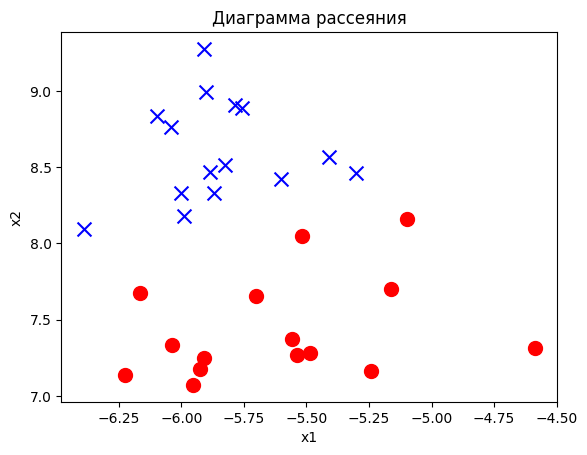

In [ ]:
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [ ]:
svm_linear = SVC(kernel='linear', C=100)
svm_linear.fit(X, y)

SVC(C=100, kernel='linear')

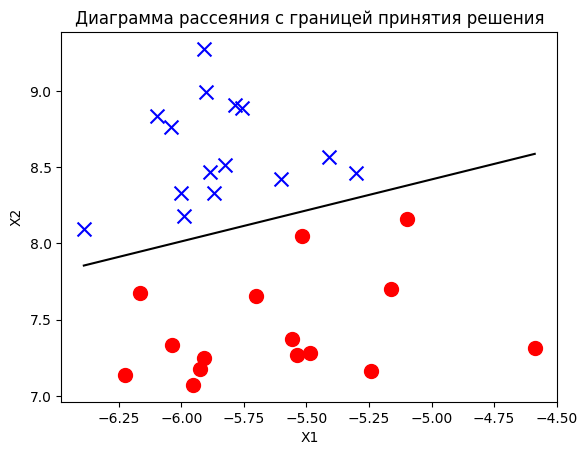

In [ ]:
X1 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])

plt.plot(X1,-svm_linear.intercept_[0]/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X1, c='k')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c границей принятия решения")
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

## **y = Xb**

## **Xb = 0**

## b0 + b1x1 + b2x2 = 0

## x2 = -b0/b2 -b1/b2*x1

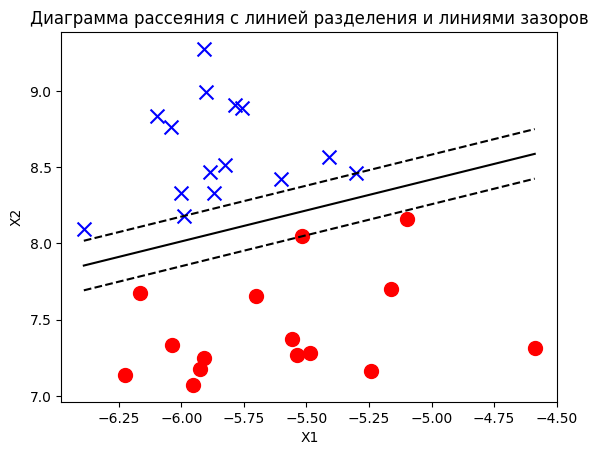

In [ ]:
plt.plot(X1,-svm_linear.intercept_[0]/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X1, c='k')

plt.plot(X1,(-svm_linear.intercept_[0]-1)/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X1,linestyle='--', c='k')
plt.plot(X1,(-svm_linear.intercept_[0]+1)/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X1,linestyle='--', c='k')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c линией разделения и линиями зазоров")
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

# **Xb = 1**

# b0 + b1x1 + b2x2 = 1

# b1x1 + b2x2 = 1 - b0

# x2 = (1 - b0)/b2 - b1/b2*x1

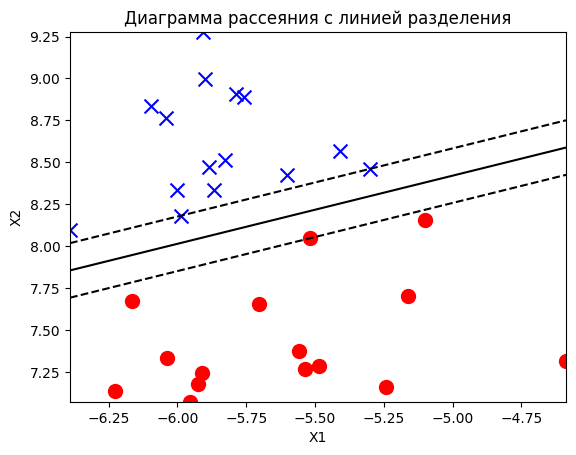

In [ ]:
X1 = np.linspace(X[:, 0].min(), X[:, 0].max(), X.shape[0])
X2 = np.linspace(X[:, 1].min(), X[:, 1].max(), X.shape[0])

X1_grid, X2_grid = np.meshgrid(X1, X2)

Z = svm_linear.intercept_[0] + svm_linear.coef_[0][0] * X1_grid +  svm_linear.coef_[0][1] * X2_grid
plt.contour(X1_grid, X2_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c линией разделения")
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [ ]:
svm_linear.coef_

array([[-2.49920793,  6.14683189]])

In [ ]:
svm_linear.intercept_

array([-64.2533988])

In [ ]:
svm_linear.support_vectors_

array([[-5.51629264,  8.04763857],
       [-5.30025769,  8.46071981],
       [-5.9879581 ,  8.18112559]])

In [ ]:
svm_linear.support_

array([ 0,  8, 29], dtype=int32)

In [ ]:
svm_linear.n_support_

array([1, 2], dtype=int32)

# *y = Xb* - decision function

In [ ]:
def plot_decision_regions(X, y, model):
    plt.scatter(model.support_vectors_[:, 0],model.support_vectors_[:, 1], linewidth=7, facecolors='green')

    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

    X1 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])
    X2 = np.linspace(X[:, 1].min(),X[:, 1].max(), X.shape[0])

    X1_grid, X2_grid = np.meshgrid(X1, X2)
    Z = model.decision_function(np.array([X1_grid.ravel(), X2_grid.ravel()]).T).reshape(X1_grid.shape)
    plt.contour(X1_grid, X2_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    plt.contourf(X1_grid, X2_grid, Z, colors='k', levels=[-1, 0, 1], alpha=0.3)

    plt.title("Диаграмма рассеяния c линией разделения и зазором")
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.show()

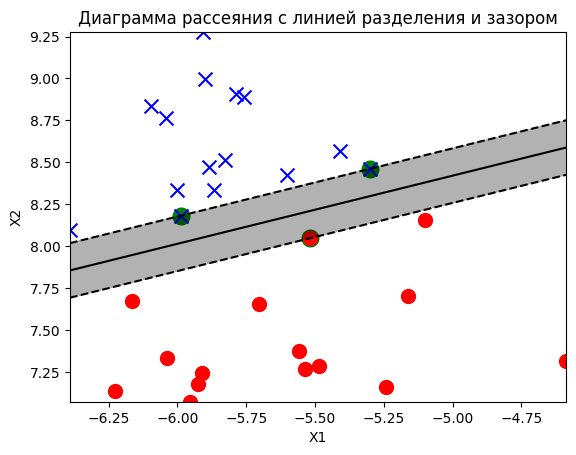

In [ ]:
plot_decision_regions(X, y, svm_linear)

In [ ]:
y_pred =  svm_linear.predict(X)

In [ ]:
y_pred

array([0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1])

In [ ]:
accuracy_score(y, y_pred)

1.0

In [ ]:
cm = confusion_matrix(y, y_pred)
cm

array([[15,  0],
       [ 0, 15]])

<Axes: >

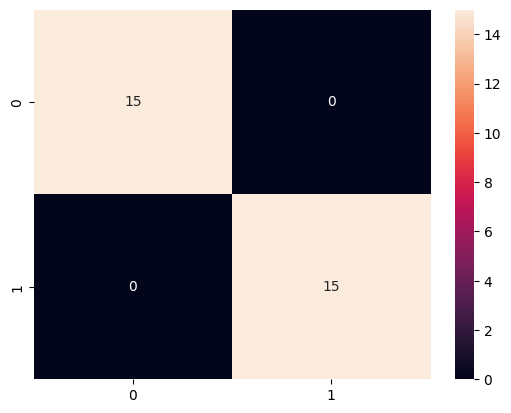

In [ ]:
import seaborn as sns
sns.heatmap(cm, annot=True)

In [ ]:
observation_new = [[-5.25, 7.5]]

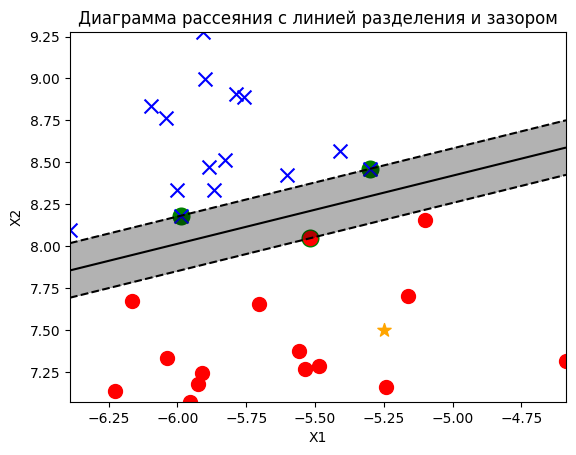

In [ ]:
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=100, color='orange')
plot_decision_regions(X, y, svm_linear)

In [ ]:
svm_linear.decision_function(observation_new)

array([-5.03131797])

In [ ]:
svm_linear.predict(observation_new)

array([0])

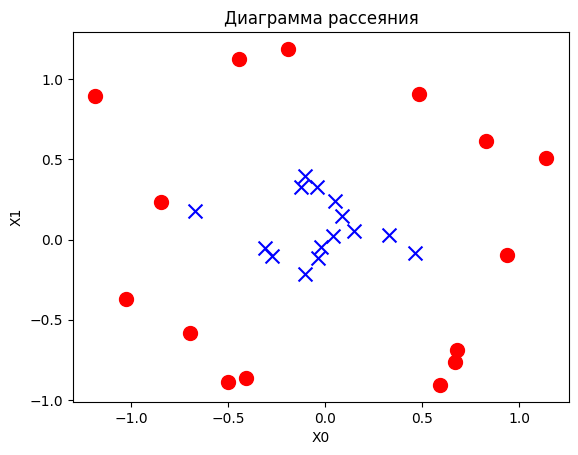

In [ ]:
X, y = make_circles(n_samples=30, random_state=5, factor=.1, noise=.2)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

In [ ]:
svm_rbf = SVC(kernel='rbf', C=10).fit(X, y)

In [ ]:
svm_rbf.n_support_

array([7, 2], dtype=int32)

In [ ]:
svm_rbf.support_

array([11, 13, 20, 21, 23, 28, 29, 25, 27], dtype=int32)

In [ ]:
svm_rbf.support_vectors_

array([[ 0.9388294 , -0.09554628],
       [-0.44607752,  1.12441808],
       [-0.84682371,  0.23287306],
       [-0.19166925,  1.18895776],
       [-0.69539045, -0.58523359],
       [ 0.68060508, -0.68615145],
       [ 0.48354792,  0.91063288],
       [-0.66975235,  0.17866445],
       [ 0.46427295, -0.08540628]])

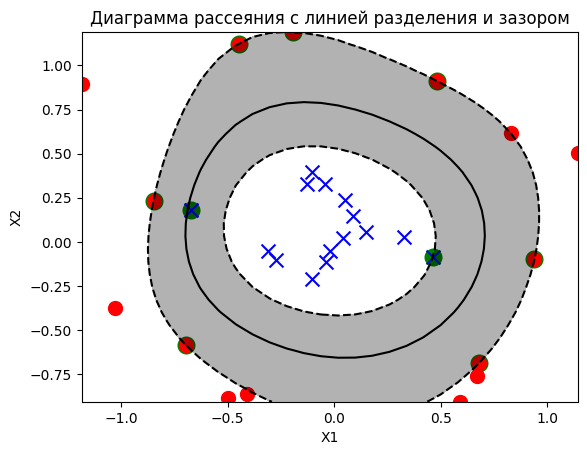

In [ ]:
plot_decision_regions(X, y, svm_rbf)

In [ ]:
y_pred =  svm_rbf.predict(X)

In [ ]:
accuracy_score(y, y_pred)

1.0

In [ ]:
confusion_matrix(y, y_pred)

array([[15,  0],
       [ 0, 15]])

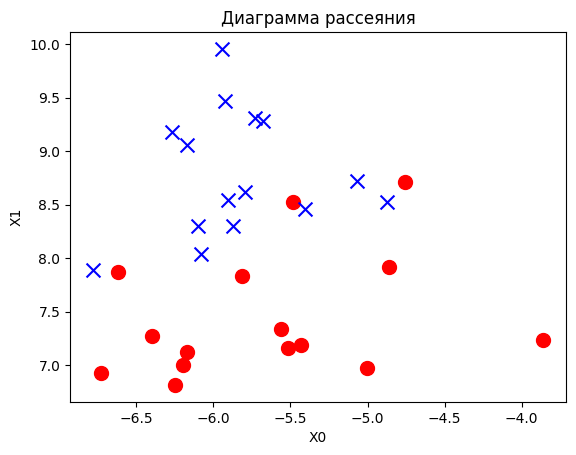

In [ ]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

In [ ]:
svm_poly = SVC(kernel='poly', degree=30, C=200).fit(X, y)

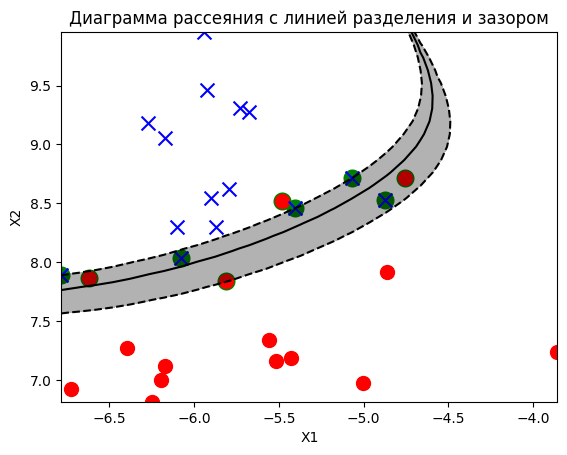

In [ ]:
plot_decision_regions(X, y, svm_poly)

In [ ]:
svm_poly.n_support_

array([4, 5], dtype=int32)

In [ ]:
y_pred =  svm_poly.predict(X)

In [ ]:
accuracy_score(y, y_pred)

0.9

In [ ]:
cm = confusion_matrix(y, y_pred)
cm

array([[13,  2],
       [ 1, 14]])

<Axes: >

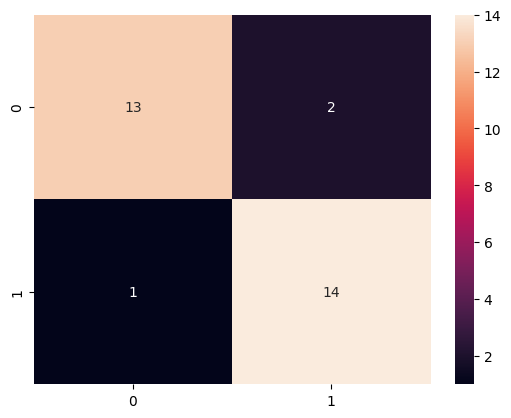

In [ ]:
import seaborn as sns
sns.heatmap(cm, annot=True)

xx:
[[-5.  -2.5  0.   2.5  5. ]
 [-5.  -2.5  0.   2.5  5. ]
 [-5.  -2.5  0.   2.5  5. ]
 [-5.  -2.5  0.   2.5  5. ]
 [-5.  -2.5  0.   2.5  5. ]]

yy:
[[-5.  -5.  -5.  -5.  -5. ]
 [-2.5 -2.5 -2.5 -2.5 -2.5]
 [ 0.   0.   0.   0.   0. ]
 [ 2.5  2.5  2.5  2.5  2.5]
 [ 5.   5.   5.   5.   5. ]]


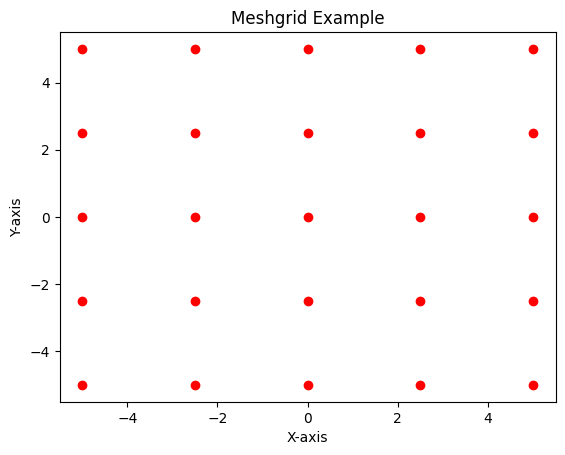

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_values = np.linspace(-5, 5, 5)
y_values = np.linspace(-5, 5, 5)

xx, yy = np.meshgrid(x_values, y_values)

print("xx:")
print(xx)
print("\nyy:")
print(yy)

plt.scatter(xx, yy, color='red')
plt.title('Meshgrid Example')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

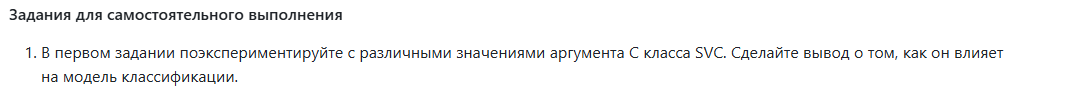

# 1

In [ ]:
svm_linear = SVC(kernel='linear', C=100)
svm_linear.fit(X, y)

SVC(C=100, kernel='linear')

In [ ]:
svm_linear.coef_

array([[-1.83830378,  4.07363695]])

In [ ]:
def plot_decision_regions(X, y, model):
    plt.scatter(model.support_vectors_[:, 0],model.support_vectors_[:, 1], linewidth=7, facecolors='green')

    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

    X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])
    X1 = np.linspace(X[:, 1].min(),X[:, 1].max(), X.shape[0])

    X0_grid, X1_grid = np.meshgrid(X0, X1)
    Z = model.decision_function(np.array([X0_grid.ravel(), X1_grid.ravel()]).T).reshape(X0_grid.shape)
    plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    plt.contourf(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], alpha=0.5)

    plt.title("Диаграмма рассеяния c линией разделения и зазором")
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.show()

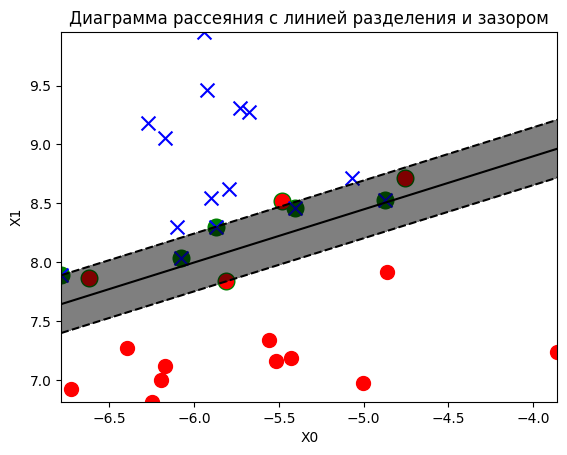

In [ ]:
plot_decision_regions(X, y, svm_linear)

In [ ]:
svm_linear.support_vectors_

array([[-5.48340969,  8.52238291],
       [-5.81131684,  7.83707625],
       [-4.75416287,  8.71477783],
       [-6.61796227,  7.86603938],
       [-4.87623828,  8.52709604],
       [-5.40598326,  8.45958294],
       [-6.78315809,  7.8895225 ],
       [-5.86995333,  8.30147083],
       [-6.07971401,  8.03780617]])

0.1

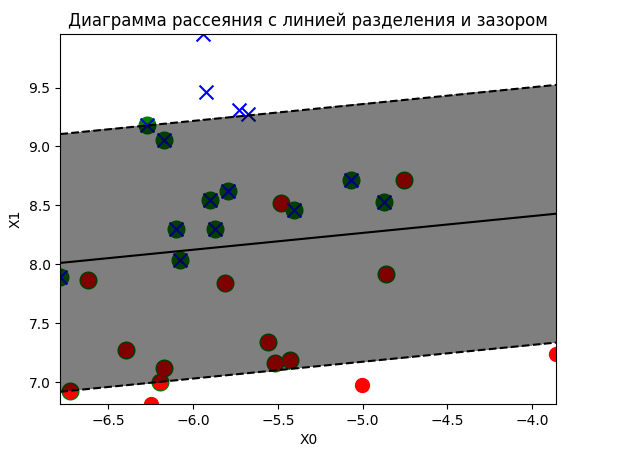

1

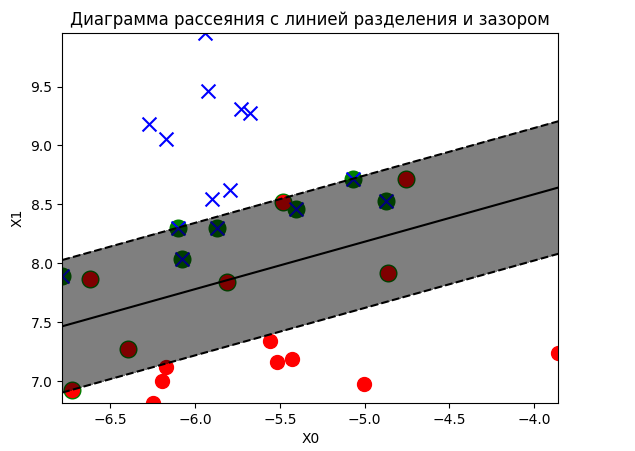

5

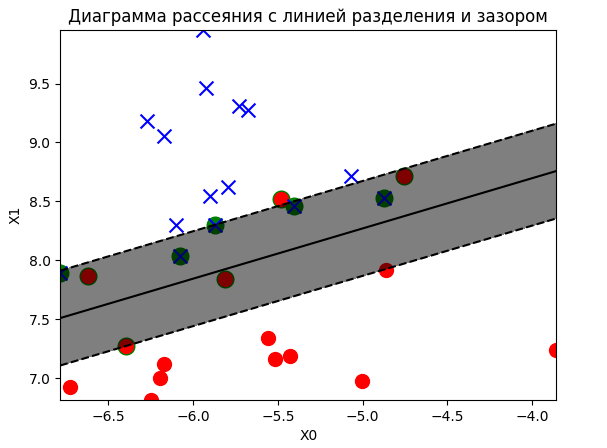

100

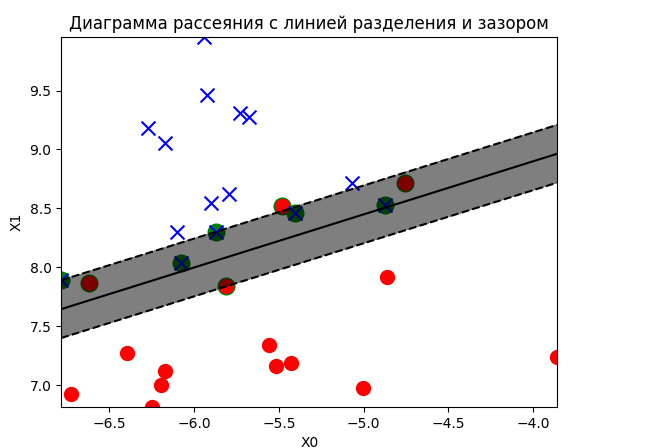

# 2

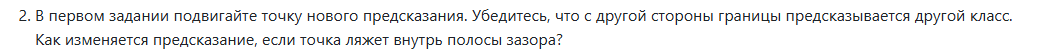

In [ ]:
observation_new = [[-5.25, 7.5]]

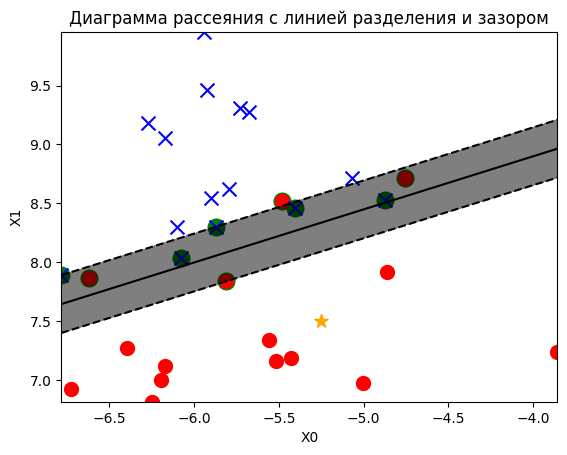

In [ ]:
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=100, color='orange')
plot_decision_regions(X, y, svm_linear)

In [ ]:
svm_linear.decision_function(observation_new)

array([-3.40525818])

In [ ]:
svm_linear.predict(observation_new)

array([0])

In [ ]:
observation_new = [[-6,9.5]]

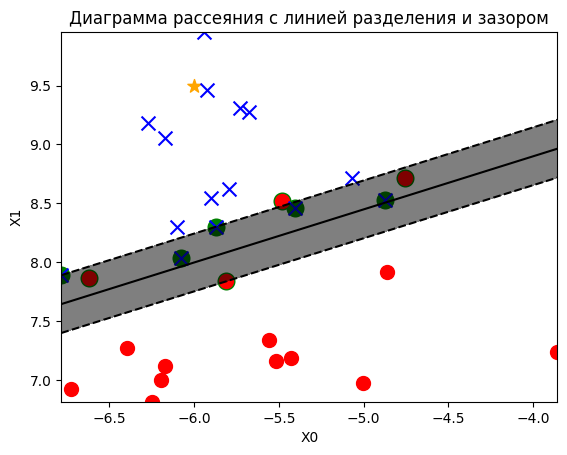

In [ ]:
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=100, color='orange')
plot_decision_regions(X, y, svm_linear)

In [ ]:
svm_linear.decision_function(observation_new)

array([6.12074357])

In [ ]:
svm_linear.predict(observation_new)

array([1])

# 3

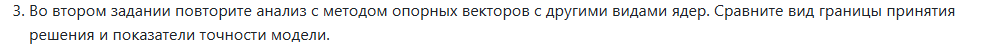

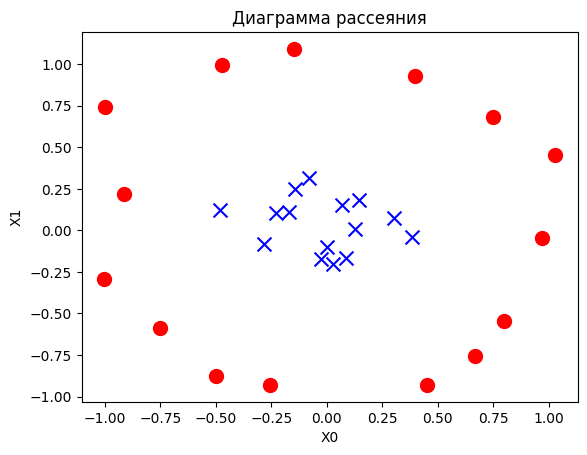

In [ ]:
X, y = make_circles(n_samples=30, random_state=5, factor=.2, noise=.1)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

In [ ]:
svm_rbf = SVC(kernel='rbf', C=100).fit(X, y)

In [ ]:
svm_rbf.n_support_
svm_rbf.support_
svm_rbf.support_vectors_

array([[-0.25564642, -0.93003714],
       [ 0.74843594,  0.67998766],
       [ 0.9694147 , -0.04777314],
       [-0.47303876,  0.99522174],
       [ 0.4503568 , -0.9289311 ],
       [-0.91248565,  0.22039237],
       [-0.75220372, -0.58650942],
       [ 0.79707527, -0.54644405],
       [ 0.39628246,  0.9308447 ],
       [-0.48159832,  0.12051898],
       [ 0.38213647, -0.04270314]])

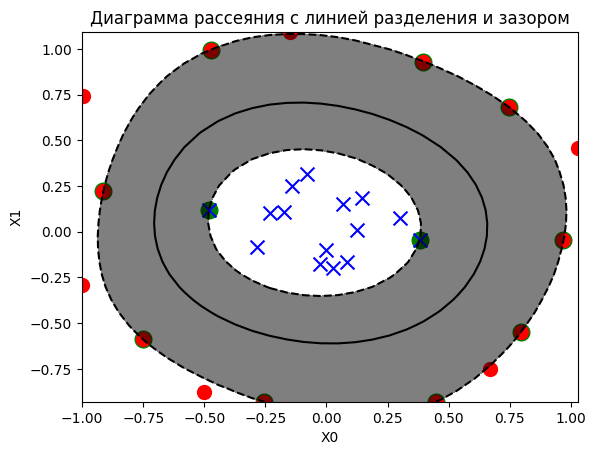

In [ ]:
plot_decision_regions(X, y, svm_rbf)

In [ ]:
y_pred =  svm_rbf.predict(X)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy_score(y, y_pred)

1.0

In [ ]:
confusion_matrix(y, y_pred)

array([[15,  0],
       [ 0, 15]])

In [ ]:
#poly

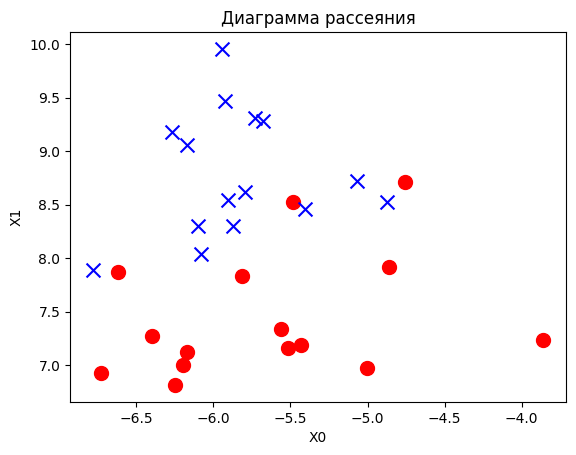

In [ ]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

In [ ]:
svm_poly = SVC(kernel='poly', degree=30, C=0.2).fit(X, y)

In [ ]:
svm_poly.n_support_
svm_poly.support_
svm_poly.support_vectors_

array([[-5.48340969,  8.52238291],
       [-5.81131684,  7.83707625],
       [-4.75416287,  8.71477783],
       [-6.61796227,  7.86603938],
       [-6.72548855,  6.9245208 ],
       [-6.39507181,  7.27123257],
       [-4.87623828,  8.52709604],
       [-5.40598326,  8.45958294],
       [-6.78315809,  7.8895225 ],
       [-5.06807681,  8.71832644],
       [-5.86995333,  8.30147083],
       [-6.07971401,  8.03780617]])

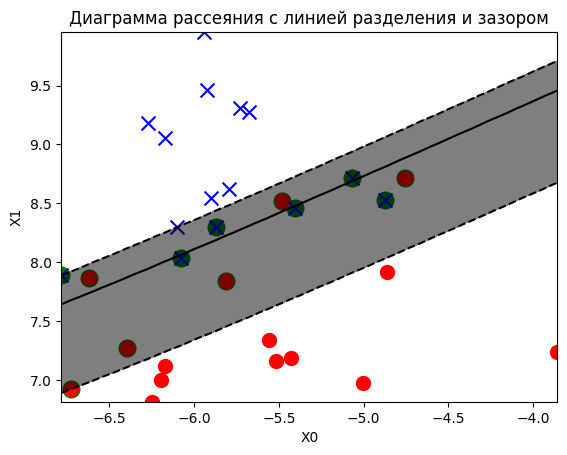

In [ ]:
plot_decision_regions(X, y, svm_poly)

In [ ]:
y_pred =  svm_poly.predict(X)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy_score(y, y_pred)

0.8333333333333334

# 4

image.png

In [ ]:
# C = 5

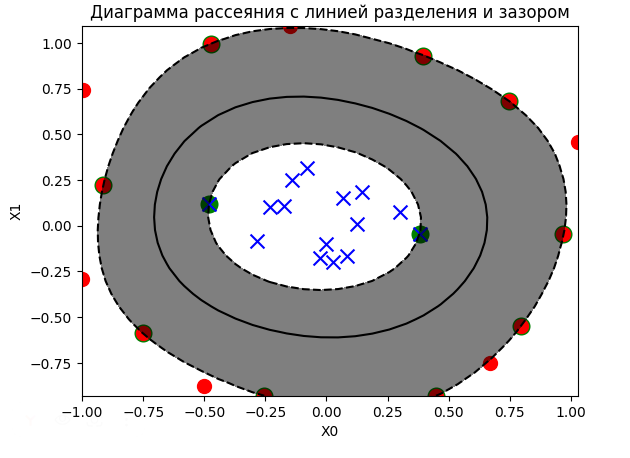

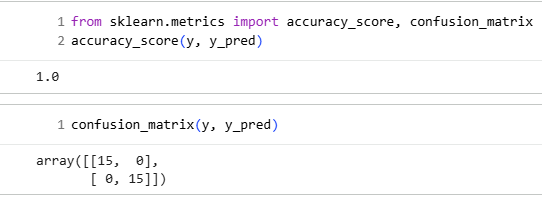

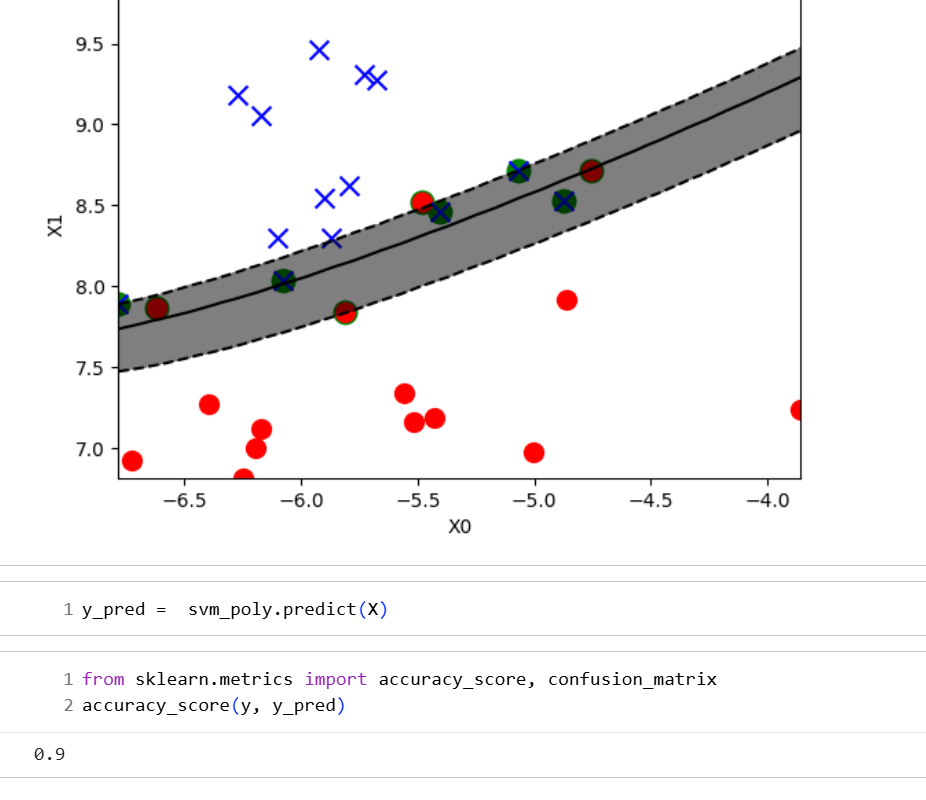

In [ ]:
# 0.2

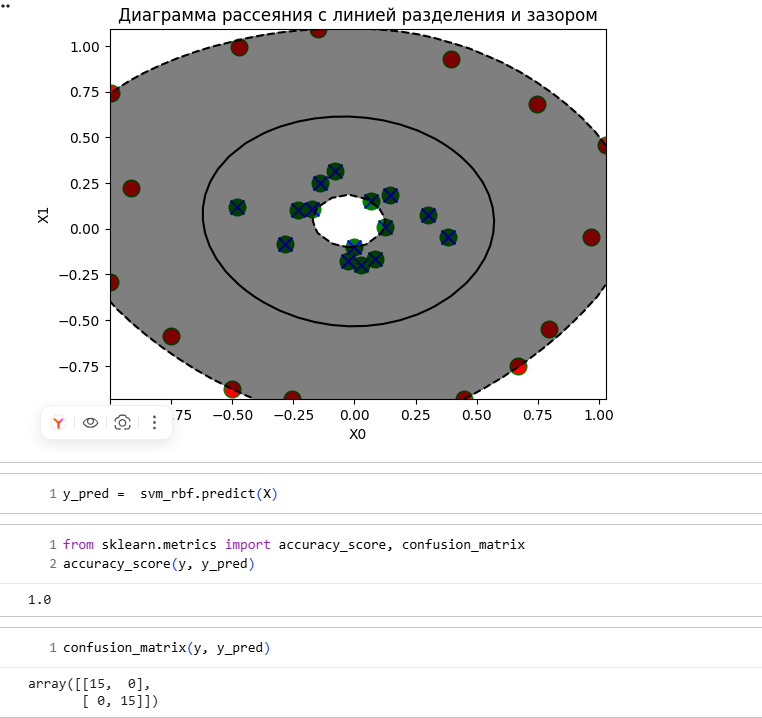

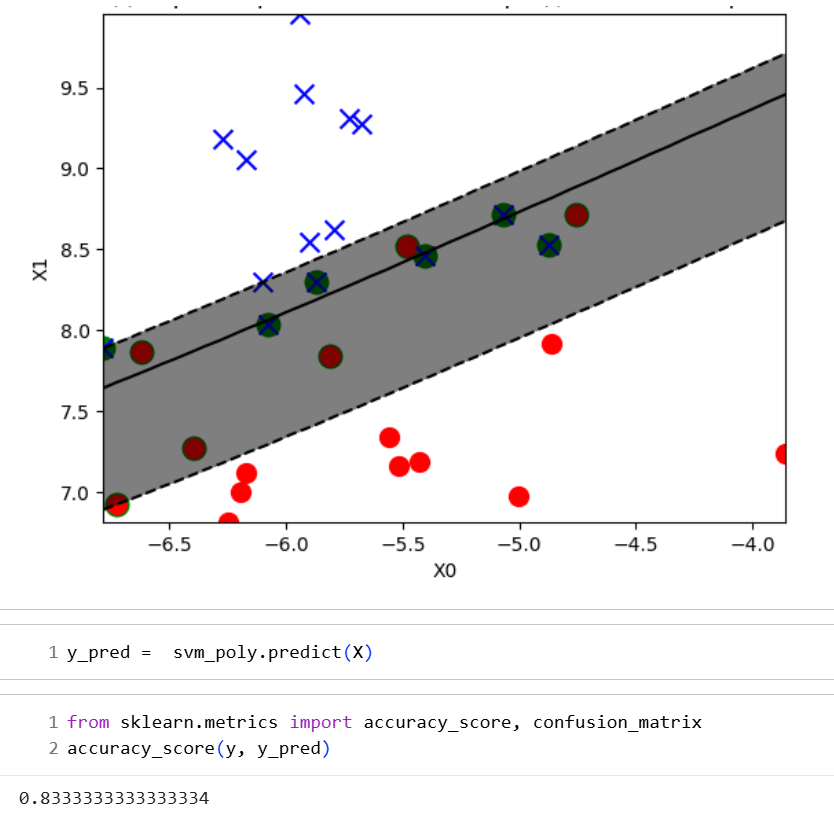

# 5

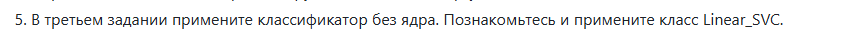

In [ ]:
from sklearn.svm import SVC, LinearSVC
from sklearn.datasets import make_blobs, make_circles
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

linear_svc = LinearSVC(C=0.2).fit(X, y)
y_pred_linear = linear_svc.predict(X)
accuracy_linear = accuracy_score(y, y_pred_linear)
print(f"LinearSVC точность: {accuracy_linear:.3f}")

LinearSVC точность: 0.767


# 6

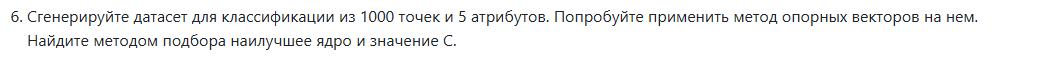

In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=5, n_classes=2, n_clusters_per_class=1,
                           n_informative=2, n_redundant=0, n_repeated=0, random_state=42)

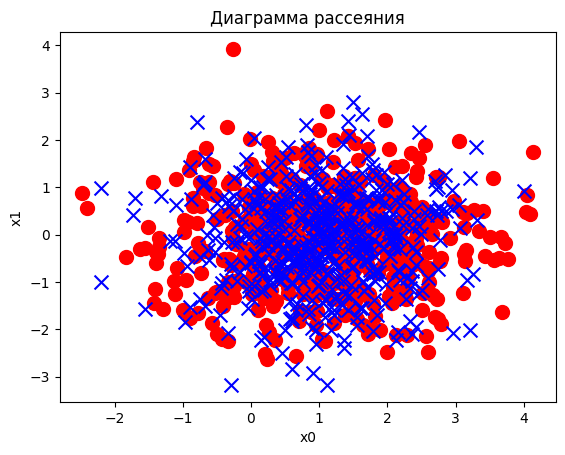

In [ ]:
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

In [ ]:
for C in [0.01, 0.1, 1, 10, 100, 1000]:
    svm_poly = SVC(kernel='poly', degree=30, C=C).fit(X, y)
    y_pred =  svm_poly.predict(X)
    accuracy= accuracy_score(y, y_pred)
    print(f"svm_poly точность: {accuracy:.3f}")

svm_poly точность: 0.669
svm_poly точность: 0.693
svm_poly точность: 0.734
svm_poly точность: 0.760
svm_poly точность: 0.787
svm_poly точность: 0.818


In [ ]:
linear_svc = LinearSVC(C=100).fit(X, y)
y_pred_linear = linear_svc.predict(X)
accuracy_linear = accuracy_score(y, y_pred_linear)
print(f"LinearSVC точность: {accuracy_linear:.3f}")

LinearSVC точность: 0.903


In [ ]:
for C in [0.01, 0.1, 1, 10, 100, 1000]:
  svm_linear = SVC(kernel='linear', C=C)
  svm_linear.fit(X, y)
  y_pred = svm_linear.predict(X)
  accuracy= accuracy_score(y, y_pred)
  print(f"Linear точность: {accuracy:.3f}")

Linear точность: 0.898
Linear точность: 0.916
Linear точность: 0.924
Linear точность: 0.924
Linear точность: 0.924
Linear точность: 0.924


In [ ]:
for C in [0.01, 0.1, 1, 10, 100, 1000]:
  svm_rbf = SVC(kernel='rbf', C=C).fit(X, y)
  y_pred =  svm_rbf.predict(X)
  accuracy= accuracy_score(y, y_pred)
  print(f"svm_rbf точность: {accuracy:.3f}")

svm_rbf точность: 0.911
svm_rbf точность: 0.915
svm_rbf точность: 0.928
svm_rbf точность: 0.947
svm_rbf точность: 0.965
svm_rbf точность: 0.983


# 7

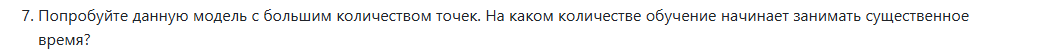

In [ ]:
import time
sample_sizes = [100, 500, 1000, 2000, 5000, 10000, 20000]
training_times = []

k = 'rbf'
C = 1000
for el in sample_sizes:
    X, y = make_classification(n_samples=el, n_features=5, n_classes=2,
                              random_state=42)
    model = SVC(kernel=k, C=C)

    start_time = time.time()
    model.fit(X, y)
    end_time = time.time()

    training_time = end_time - start_time
    training_times.append(training_time)

    print(f"{el:6d} - {training_time:.3f}")

   100 - 0.005
   500 - 0.073
  1000 - 0.546
  2000 - 1.105
  5000 - 3.529
 10000 - 10.451
 20000 - 44.675


# 8

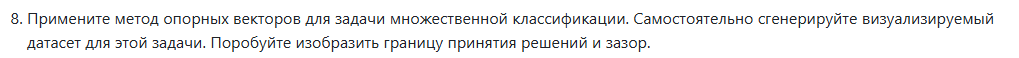

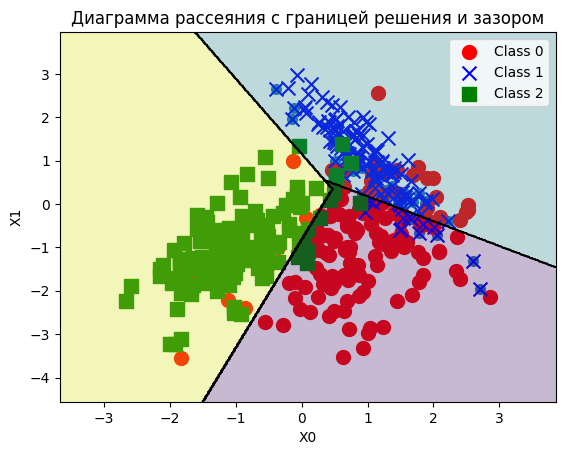

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.svm import SVC

X, y = make_classification(n_samples=400, n_features=2, n_informative=2,
                          n_redundant=0, n_clusters_per_class=1,
                          n_classes=3, random_state=42)

model = SVC(kernel='linear', C=1.0)
model.fit(X, y)

def plot_decision_regions(X, y, model):
    plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                linewidth=2)
    plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0], marker="o", c='r', s=100, label='Class 0')
    plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1], marker="x", c='b', s=100, label='Class 1')
    plt.scatter(X[:, 0][y == 2], X[:, 1][y == 2], marker="s", c='g', s=100, label='Class 2')

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.contour(xx, yy, Z, colors='k', linewidths=1, linestyles='-')

    plt.title("Диаграмма рассеяния с границей решения и зазором")
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.legend()
    plt.show()
plot_decision_regions(X, y, model)

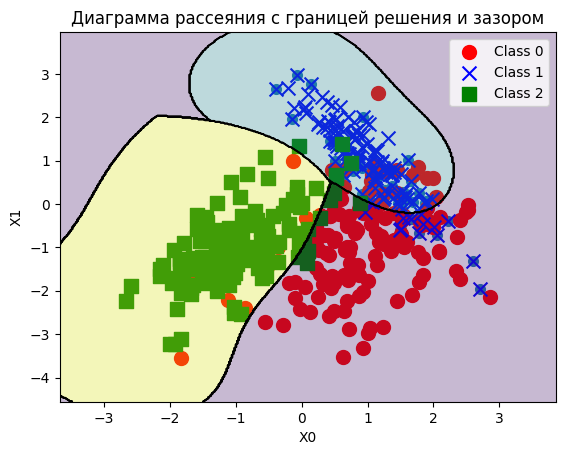

<Figure size 640x480 with 0 Axes>

In [ ]:
svm_rbf = SVC(kernel='rbf', C=1.0)
svm_rbf.fit(X, y)
plot_decision_regions(X, y, svm_rbf)

plt.tight_layout()
plt.show()

In [ ]:
y_pred_rbf = svm_rbf.predict(X)
y_pred_linear = model.predict(X)

print("RBF:")
print(f"Точность: {accuracy_score(y, y_pred_rbf):.3f}")
print("Матрица ошибок:")
print(confusion_matrix(y, y_pred_rbf))

print("\nлинейное ядро:")
print(f"Точность: {accuracy_score(y, y_pred_linear):.3f}")
print("Матрица ошибок:")
print(confusion_matrix(y, y_pred_linear))


RBF:
Точность: 0.868
Матрица ошибок:
[[108  19   8]
 [ 14 119   0]
 [  7   5 120]]

линейное ядро:
Точность: 0.855
Матрица ошибок:
[[104  23   8]
 [ 14 119   0]
 [  8   5 119]]


# 9

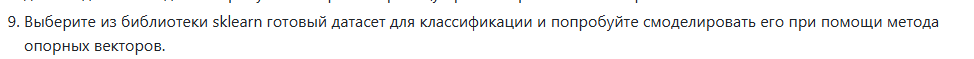

In [ ]:
from sklearn import datasets
from sklearn.svm import SVC

digits = datasets.load_digits()
X = digits.data
y = digits.target

svm_rbf = SVC(kernel='rbf', C=10).fit(X, y)
y_pred =  svm_rbf.predict(X)
accuracy= accuracy_score(y, y_pred)
print(f"svm_rbf точность: {accuracy:.3f}")

svm_rbf точность: 1.000


# 10

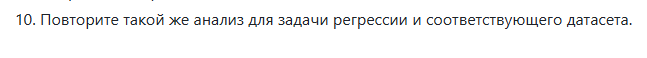

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

housing = fetch_california_housing()
X = housing.data
y = housing.target

In [ ]:
C_values = [0.01, 0.1, 1, 10, 100]

for C in C_values:
    svr = SVR(kernel='rbf', C=C)
    svr.fit(X, y)
    y_pred = svr.predict(X)
    r2 = r2_score(y, y_pred)
    print(f"C={C}: R2 = {r2:.3f}")

C=0.01: R2 = -0.055
C=0.1: R2 = -0.050
C=1: R2 = -0.017
C=10: R2 = 0.187
C=100: R2 = 0.534
